<a href="https://colab.research.google.com/github/Pranitha3197/Loan-Prediction/blob/main/loan%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install shap
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

In [16]:
train = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
test = pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [19]:
print(train.shape)
train.info()
train.describe()

(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [20]:
for df in [train, test]:

    df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
    df['Married'].fillna(df['Married'].mode()[0], inplace=True)
    df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
    df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

    df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
    df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
    df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_151/2092791928.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_151/2092791928.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [21]:
for df in [train, test]:

    df['Dependents'] = df['Dependents'].replace('3+',3).astype(int)

    df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

    df["Income_Loan_Ratio"] = df["TotalIncome"] / df["LoanAmount"]

    df["LoanAmount_log"] = np.log(df["LoanAmount"])

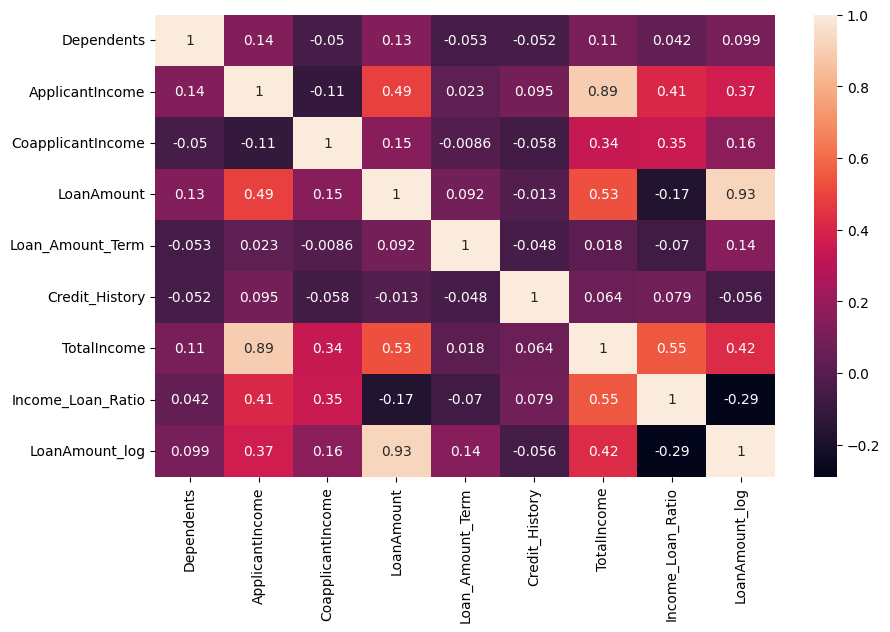

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [23]:
le = LabelEncoder()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = le.fit_transform(train[col])

for col in test.columns:
    if test[col].dtype == 'object':
        test[col] = le.fit_transform(test[col])


In [24]:
X = train.drop(["Loan_Status","Loan_ID"], axis=1)
y = train["Loan_Status"]

test_ids = test["Loan_ID"]
test = test.drop("Loan_ID", axis=1)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)

In [26]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
models = {

"Logistic Regression": LogisticRegression(max_iter=1000),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(),

"KNN": KNeighborsClassifier(),

"SVM": SVC(probability=True),

"Gradient Boosting": GradientBoostingClassifier(),

"XGBoost": XGBClassifier(),

"LightGBM": LGBMClassifier(),

"CatBoost": CatBoostClassifier(verbose=0)

}

In [29]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

print(results)

[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Logistic Regression': 0.8292682926829268, 'Decision Tree': 0.7154471544715447, 'Random Forest': 0.8048780487804879, 'KNN': 0.7642276422764228, 'SVM': 0.8455284552845529, 'Gradient Boosting': 0.8130081300813008, 'XGBoost': 0.7967479674796748, 'LightGBM': 0.8048780487804879, 'CatBoost': 0.8048780487804879}


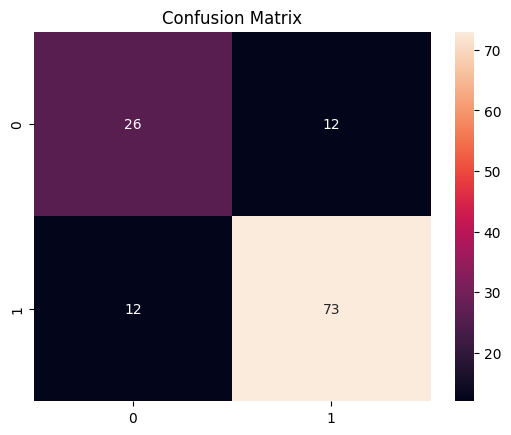

In [30]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

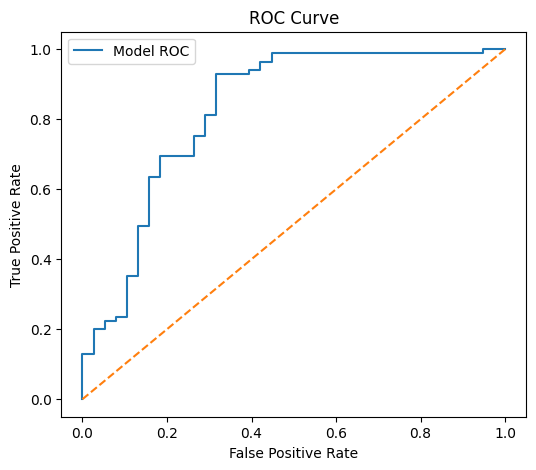

ROC AUC Score: 0.8260061919504644


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Model ROC")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

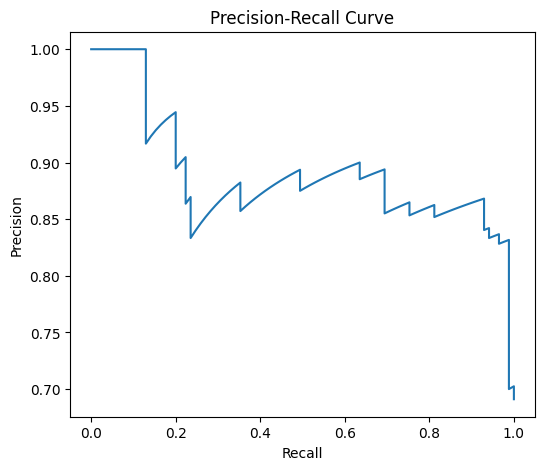

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


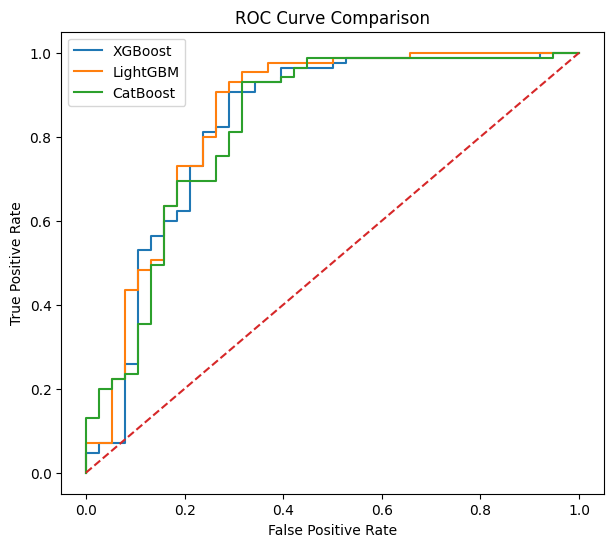

In [ ]:
xgb_model = XGBClassifier()
lgb_model = LGBMClassifier()
cat_model = CatBoostClassifier(verbose=0)

xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

models = {
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

plt.figure(figsize=(7,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

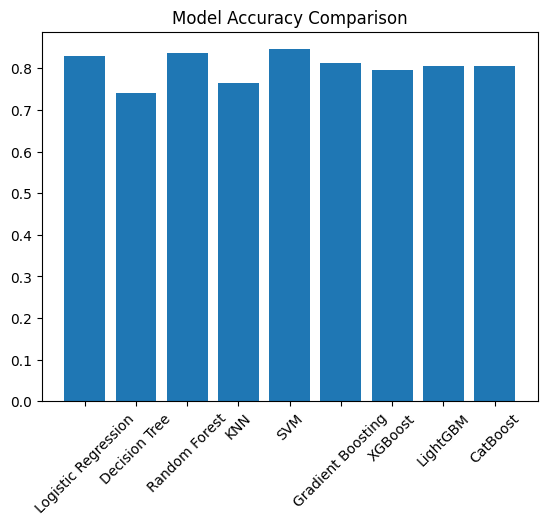

In [ ]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
best_model = XGBClassifier()

best_model.fit(X_train,y_train)

pred = best_model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.64      0.76      0.70        38
           1       0.88      0.81      0.85        85

    accuracy                           0.80       123
   macro avg       0.76      0.79      0.77       123
weighted avg       0.81      0.80      0.80       123



In [37]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68        38
           1       0.86      0.86      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.77      0.77       123
weighted avg       0.80      0.80      0.80       123



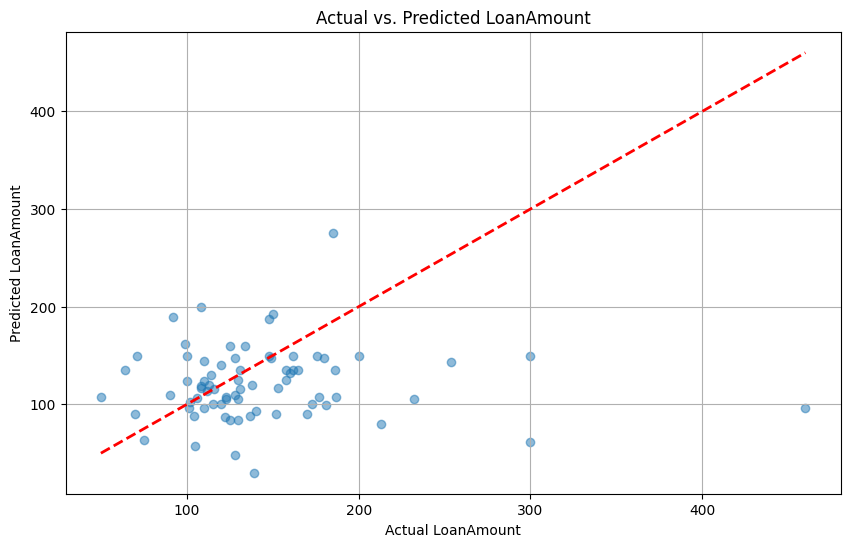

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual LoanAmount")
plt.ylabel("Predicted LoanAmount")
plt.title("Actual vs. Predicted LoanAmount")
plt.grid(True)
plt.show()

<Axes: >

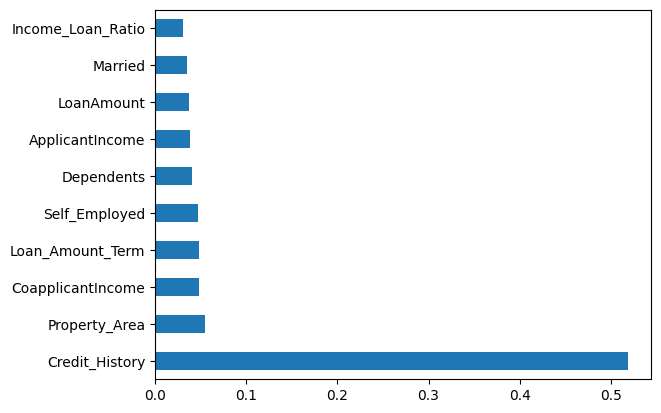

In [ ]:
importances = best_model.feature_importances_

feat = pd.Series(importances,index=X.columns)

feat.nlargest(10).plot(kind='barh')

In [ ]:
param_grid = {

'n_estimators':[200,400,600],

'max_depth':[3,4,5]

}

grid = GridSearchCV(
XGBClassifier(),
param_grid,
cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


In [34]:
import pickle

pickle.dump(model, open("loan_model.pkl","wb"))

In [ ]:
pip install shap

In [ ]:
pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
lgb = LGBMClassifier()

lgb.fit(X_train, y_train)

pred = lgb.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test,pred))

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
cat = CatBoostClassifier(verbose=0)

cat.fit(X_train, y_train)

pred = cat.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test,pred))

CatBoost Accuracy: 0.04054054054054054


In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    loss_function='RMSE', # Changed to RMSE for regression
    eval_metric='RMSE', # Changed to RMSE for regression
    random_seed=42,
    verbose=200
)

model.fit(X_train, y_train)

0:	learn: 60.7378086	total: 3.28ms	remaining: 3.28s
200:	learn: 31.9335649	total: 227ms	remaining: 904ms
400:	learn: 25.1103229	total: 443ms	remaining: 662ms
600:	learn: 20.1930469	total: 830ms	remaining: 551ms
800:	learn: 17.2302898	total: 1.08s	remaining: 269ms
999:	learn: 15.1289606	total: 1.34s	remaining: 0us


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [ ]:
param_grid_catboost = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

print(param_grid_catboost)

{'iterations': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1], 'depth': [4, 6, 8], 'l2_leaf_reg': [1, 3, 5]}


In [ ]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(random_seed=42, verbose=0) # Set verbose to 0 to suppress fitting output for each combination

grid_search = GridSearchCV(
    estimator=catboost_model,
    param_grid=param_grid_catboost,
    cv=3, # Using a smaller CV for quicker execution; typically 5 or more is used
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE found: ", -grid_search.best_score_)

Best parameters found:  {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best RMSE found:  2613.7890636321795


In [ ]:
pred_test = best_model.predict(test)

pred_test = np.where(pred_test==1,"Y","N")

In [ ]:
submission = pd.DataFrame({

"Loan_ID": test_ids,

"Loan_Status": pred_test

})

submission.to_csv("loan_submission.csv",index=False)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4
)

lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03
)

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    verbose=0
)

stack_model = StackingClassifier(

    estimators=[
        ('xgb', xgb),
        ('lgb', lgb),
        ('cat', cat)
    ],

    final_estimator=LogisticRegression()

)

stack_model.fit(X_train, y_train)

pred = stack_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test,pred))

[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 269, number of negative: 270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 539, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499072 -> initscore=-0.003711
[LightGBM] [Info] Start training from score -0.003711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 270, number of negative: 269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1026
[LightGBM] [Info] Number of data points in the train set: 539, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500928 -> initscore=0.003711
[LightGBM] [Info] Start training from score 0.003711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Accuracy: 0.7967479674796748


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
explainer = shap.TreeExplainer(best_model)

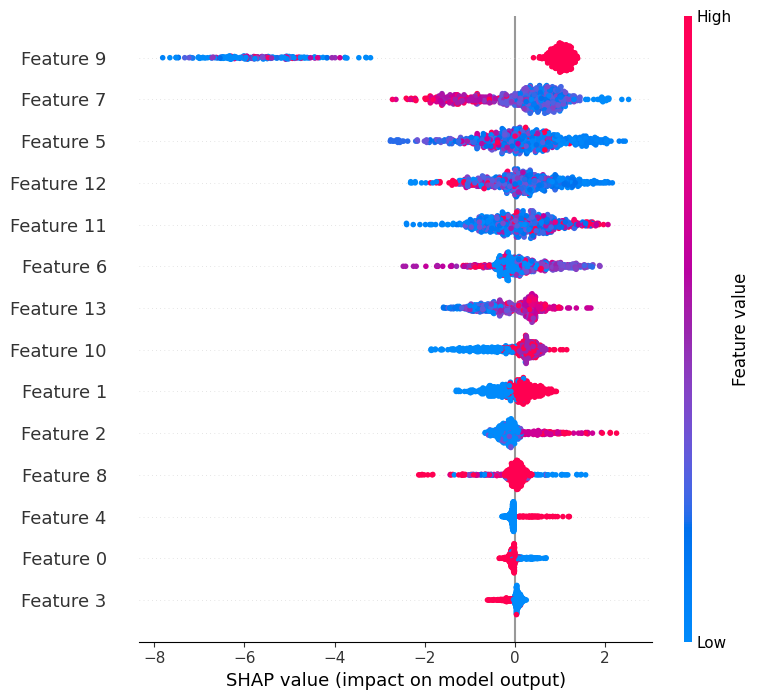

In [ ]:
shap_values_train = explainer.shap_values(X_train)
shap.summary_plot(shap_values_train, X_train)

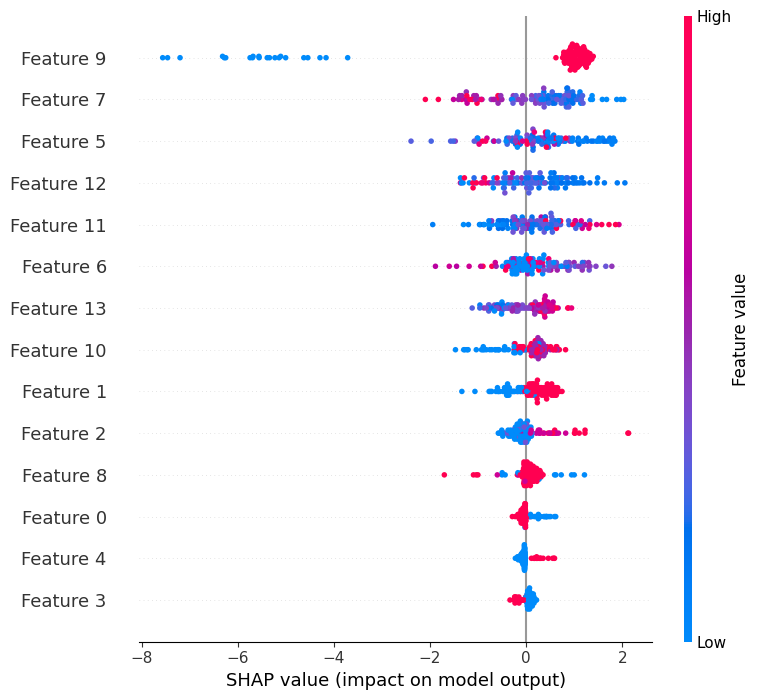

In [ ]:
shap_values_test = explainer.shap_values(X_test)
shap.summary_plot(shap_values_test, X_test)

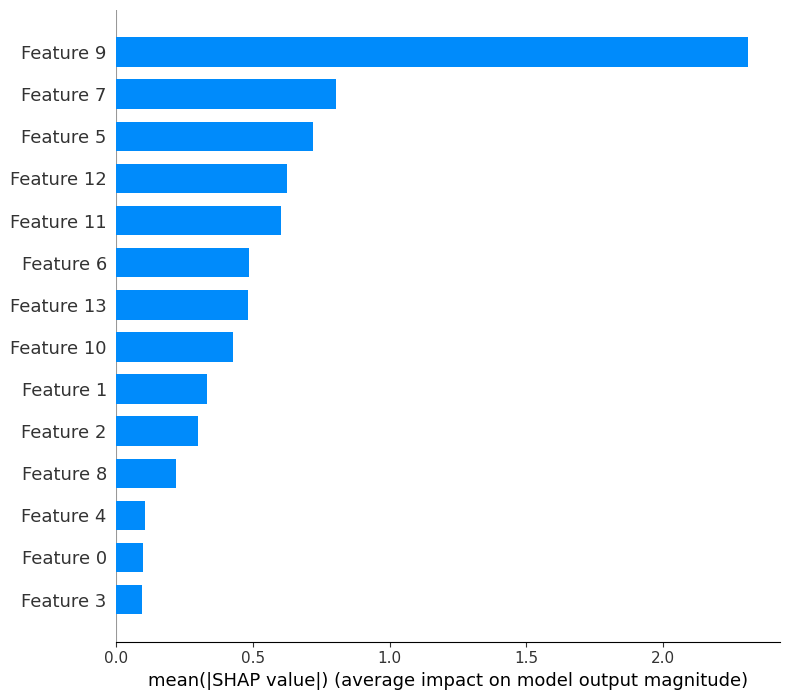

In [ ]:
shap.summary_plot(shap_values_train, X_train, plot_type="bar")

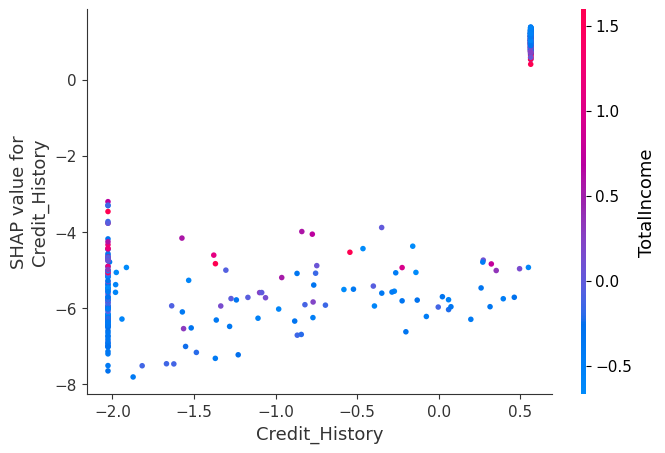

In [ ]:
shap.dependence_plot("Credit_History", shap_values_train, X_train, feature_names=X.columns)

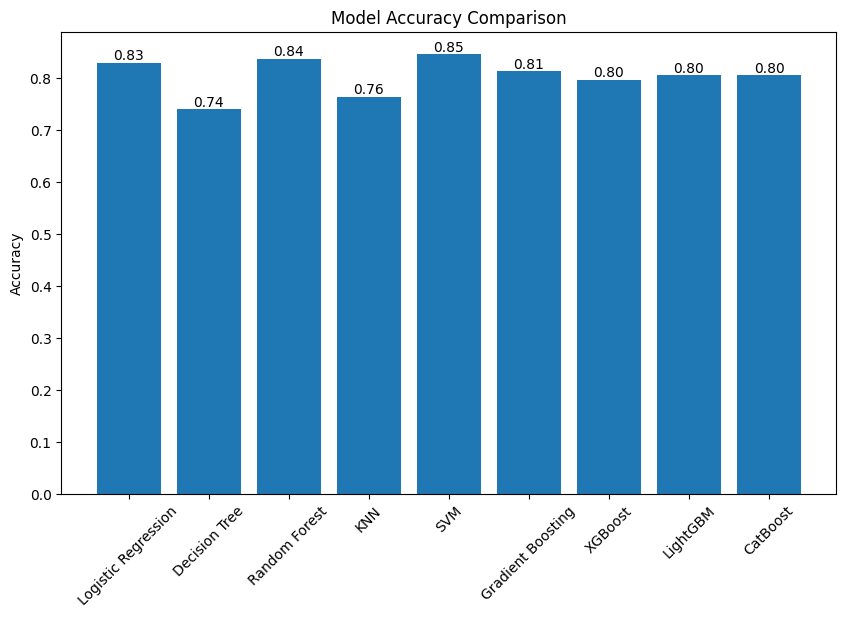

In [ ]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

plt.bar(model_names, accuracies)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
import pandas as pd

leaderboard = pd.DataFrame({

"Model": results.keys(),
"Accuracy": results.values()

})

leaderboard = leaderboard.sort_values(
by="Accuracy",
ascending=False
).reset_index(drop=True)

leaderboard["Rank"] = leaderboard.index + 1

leaderboard = leaderboard[["Rank","Model","Accuracy"]]

leaderboard.style.background_gradient(cmap="Blues")

,Rank,Model,Accuracy
0,1,SVM,0.845528
1,2,Random Forest,0.837398
2,3,Logistic Regression,0.829268
3,4,Gradient Boosting,0.813008
4,5,LightGBM,0.804878
5,6,CatBoost,0.804878
6,7,XGBoost,0.796748
7,8,KNN,0.764228
8,9,Decision Tree,0.739837


In [ ]:
best_model = leaderboard.iloc[0]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: SVM
Best Accuracy: 0.8455284552845529


In [ ]:
def benchmark_models(models, X_train, X_test, y_train, y_test):

    results = []

    for name, model in models.items():

        start = time.time()

        model.fit(X_train, y_train)

        train_time = time.time() - start

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:,1]

        accuracy = accuracy_score(y_test, pred)
        precision = precision_score(y_test, pred)
        recall = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        auc = roc_auc_score(y_test, prob)

        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": auc,
            "Training Time (s)": train_time
        })

    return pd.DataFrame(results)

In [ ]:
leaderboard = benchmark_models(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

leaderboard = leaderboard.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

leaderboard

[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
0,Random Forest,0.853659,0.894118,0.894118,0.894118,0.843963,0.391998
1,SVM,0.845528,0.843750,0.952941,0.895028,0.798452,0.175068
2,Logistic Regression,0.829268,0.863636,0.894118,0.878613,0.857585,0.011985
3,Gradient Boosting,0.813008,0.860465,0.870588,0.865497,0.805882,0.486836
4,LightGBM,0.804878,0.876543,0.835294,0.855422,0.848297,0.123372
5,CatBoost,0.804878,0.858824,0.858824,0.858824,0.826006,5.974491
6,XGBoost,0.796748,0.884615,0.811765,0.846626,0.827864,0.375911
7,KNN,0.764228,0.825581,0.835294,0.830409,0.750310,0.003033
8,Decision Tree,0.731707,0.871429,0.717647,0.787097,0.740402,0.008454
